# Social network analysis: ERGM

This tutorial is based on the Introduction to Statistical Modeling of Network Data with Exponential Random Graph Models (ERGMs) using R statnet software, available at:
https://statnet.org/workshop-ergm/ergm_tutorial.html

We will demonstrate the usage of the statnet packages:

1) network – storage and manipulation of network data

2) ergm – statistical tools for estimating ERGMs, model assessment, and network simulation

For additional functionality that is not covered today see the `ergm` package.

In [ ]:
# install packages
install.packages("statnet")
install.packages("intergraph",dependencies = TRUE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘DEoptimR’, ‘rbibutils’, ‘robustbase’, ‘coda’, ‘ergm.multi’, ‘Rdpack’, ‘trust’, ‘lpSolveAPI’, ‘rle’, ‘networkLite’, ‘tergm’, ‘ergm.count’, ‘sna’, ‘tsna’, ‘ergm’, ‘network’, ‘networkDynamic’, ‘statnet.common’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘igraph’




In [ ]:
# install the igraph library from GitHub
install.packages("remotes")
remotes::install_github("igraph/rigraph")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)





── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmp0wwKaa/remotesac5d9937cd/igraph-rigraph-0d33d45/DESCRIPTION’ ... OK
* preparing ‘igraph’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* running ‘cleanup’
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘igraph_2.1.4.9004.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# laoding the libraries
library(readr)
library(intergraph)
library(igraph)
library(statnet)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: tergm

Loading required package: ergm

Loading required package: network


‘network’ 1.19.0 (2024-12-08), part of the Statnet Project
* ‘news(package="network")’ for changes since last version
* ‘citation("network")’ for citation information
* ‘https://statnet.org’ for help, support, and other information



Attaching package: ‘network’


The following objects are masked from ‘package:igraph’:

    %c%, %s%, add.edges, add.vertices, delete.edges, delete.vertices,
    get.edge.attribute, get.edges, get.vertex.attribute, is.bipartite,
    is.directed, list.edge.attributes, list.vertex.attributes,
    set.edge.attribute, set.vertex.attribute



‘ergm’ 4.8.1 (2025-01-20), part of the Statnet Project
* ‘news(package="ergm")’ for changes since last version
* ‘citation("ergm")’ for citation i

## Upload edge-list file

You first need to upload the files from your local machine to Colab using the folder icon to the left

In [ ]:
# Install required package
install.packages("googledrive")
# Load the library
library(googledrive)

# Authenticate with Google Drive
drive_auth()  # This will prompt you to log in and grant permissions


# File ID from Google Drive
file_id <- "1wrBPlCBXaFKyXL3bBv1rGDHArWZ38ZSG"

# Download the file and get the temporary local path
file_path <- drive_download(as_id(file_id), overwrite = TRUE)$local_path

# Read the file into a DataFrame
df <- read.csv(file_path)

# Display the first few rows of the DataFrame
head(df)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Is it OK to cache OAuth access credentials in the folder ~/.cache/gargle
between R sessions?
1: Yes
2: No


Selection: 1


Please point your browser to the following url: 

https://accounts.google.com/o/oauth2/v2/auth?client_id=603366585132-frjlouoa3s2ono25d2l9ukvhlsrlnr7k.apps.googleusercontent.com&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email&redirect_uri=https%3A%2F%2Fwww.tidyverse.org%2Fgoogle-callback%2F&response_type=code&state=021b0cfd8711cb24e45113178708fd1b&access_type=offline&prompt=consent



Enter authorization code: eyJjb2RlIjoiNC8wQVNWZ2kzS1ByMUJ6RkxBMXRTNWwtd3g1cTJaUGtHdVhFMldlTFJpZENDUHdRV0xncHljN3QwUlUwSjRjRFRKRWdJMHdvQSIsInN0YXRlIjoiMDIxYjBjZmQ4NzExY2IyNGU0NTExMzE3ODcwOGZkMWIifQ==


File downloaded:

• MOT_edges.csv <id: 1wrBPlCBXaFKyXL3bBv1rGDHArWZ38ZSG>

Saved locally as:

• MOT_edges.csv



,Source,Target,PassengerNumber,ComplaintsNumber
,<int>,<int>,<int>,<int>
1,41700,42834,3,2
2,47266,42834,1,1
3,41664,41576,4,2
4,42289,41576,3,1
5,41390,42713,2,1
6,42041,42709,3,1


In [ ]:
###### Sorce

#edge_list <- read.csv("/content/MOT_edges.csv")

edge_list <- data.frame(df)

In [ ]:
head(df)

,Source,Target,PassengerNumber,ComplaintsNumber
,<int>,<int>,<int>,<int>
1,41700,42834,3,2
2,47266,42834,1,1
3,41664,41576,4,2
4,42289,41576,3,1
5,41390,42713,2,1
6,42041,42709,3,1


## Create a graph object

In [ ]:
g <- graph_from_data_frame(edge_list, directed = TRUE)

In [ ]:
g

In [ ]:
#don't use igraph and statnet at the same time, they have many functions with the same names
detach("package:igraph")

In [ ]:
net <- asNetwork(g)
net

 Network attributes:
  vertices = 6325 
  directed = TRUE 
  hyper = FALSE 
  loops = TRUE 
  multiple = TRUE 
  bipartite = FALSE 
  total edges= 15399 
    missing edges= 0 
    non-missing edges= 15399 

 Vertex attribute names: 
    vertex.names 

 Edge attribute names not shown 

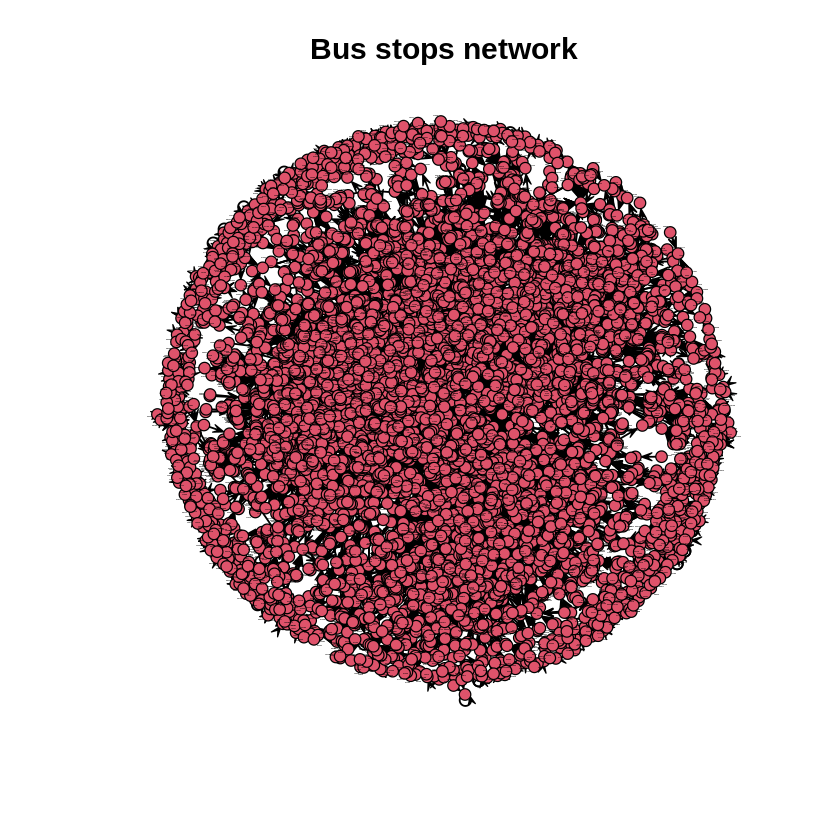

In [ ]:
# Plot the network with vertex size proportional to wealth
plot(net,
     vertex.cex=1,
     label = network.vertex.names(net),
     label.cex = 0.1,   # גודל התוויות
     main="Bus stops network", cex.main=1.5
     )

## Create an ERGM model


A list of ERGM terms can be found here: http://statnet.org/nme/d2-ergmterms.html

In [ ]:
m1 = ergm(net ~ edges)

[1] "Warning:  This network contains loops"


Starting maximum pseudolikelihood estimation (MPLE):

Obtaining the responsible dyads.

Evaluating the predictor and response matrix.

Maximizing the pseudolikelihood.

Finished MPLE.

Evaluating log-likelihood at the estimate. 




In [ ]:
summary(m1)

Call:
ergm(formula = net ~ edges)

Maximum Likelihood Results:

       Estimate Std. Error MCMC % z value Pr(>|z|)    
edges -8.209209   0.009586      0  -856.3   <1e-04 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

     Null Deviance: 55459572  on 40005625  degrees of freedom
 Residual Deviance:   200469  on 40005624  degrees of freedom
 
AIC: 200471  BIC: 200487  (Smaller is better. MC Std. Err. = 0)

In [ ]:
m2 = ergm(net ~ edges + mutual)

[1] "Warning:  This network contains loops"


Starting maximum pseudolikelihood estimation (MPLE):

Obtaining the responsible dyads.

Evaluating the predictor and response matrix.

Maximizing the pseudolikelihood.

Finished MPLE.

Starting Monte Carlo maximum likelihood estimation (MCMLE):

Iteration 1 of at most 60:

Warning message:
“‘glpk’ selected as the solver, but package ‘Rglpk’ is not available; falling back to ‘lpSolveAPI’. This should be fine unless the sample size and/or the number of parameters is very big.”
1 
Optimizing with step length 0.1133.

The log-likelihood improved by 2.8240.

Estimating equations are not within tolerance region.

Iteration 2 of at most 60:

1 
Optimizing with step length 0.1730.

The log-likelihood improved by 2.4636.

Estimating equations are not within tolerance region.

Iteration 3 of at most 60:

1 
Optimizing with step length 0.2733.

The log-likelihood improved by 2.8076.

Estimating equations are not within tolerance region.

Iteration 4 of at most 60:

1 
Optimizing with step length 

In [ ]:
summary(m2)

Call:
ergm(formula = net ~ edges + mutual)

Monte Carlo Maximum Likelihood Results:

        Estimate Std. Error MCMC % z value Pr(>|z|)    
edges  -8.267299   0.009788      0 -844.64   <1e-04 ***
mutual  5.459401   0.060360      0   90.45   <1e-04 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

     Null Deviance: 55459572  on 40005625  degrees of freedom
 Residual Deviance:   197755  on 40005623  degrees of freedom
 
AIC: 197759  BIC: 197790  (Smaller is better. MC Std. Err. = 10.37)

In [ ]:
m2.gof <- gof(m2)
m2.gof


# higher p-values are good since here I want to accept H0 that the networks are the same (my simulation worked) rather than regect H0 (i.e. the networks are not the same)


Goodness-of-fit for in-degree 

            obs  min    mean  max MC p-value
idegree0   4726 1101 1215.67 2115       0.00
idegree1    403 1884 1963.27 2068       0.00
idegree2    281 1071 1649.59 1756       0.00
idegree3    159  446  914.16  990       0.00
idegree4    111  212  388.16  447       0.00
idegree5     89  108  132.55  167       0.00
idegree6     80   22   39.62   77       0.00
idegree7     66    3   11.95   52       0.00
idegree8     47    0    3.71   41       0.00
idegree9     39    0    1.69   30       0.00
idegree10    34    0    0.95   19       0.00
idegree11    23    0    0.67   13       0.00
idegree12    36    0    0.53   17       0.00
idegree13    30    0    0.40   12       0.00
idegree14    20    0    0.35    9       0.00
idegree15    18    0    0.29   10       0.00
idegree16    16    0    0.26    9       0.00
idegree17    13    0    0.11    5       0.00
idegree18     5    0    0.14    7       0.04
idegree19     8    0    0.27   14       0.02
idegree20    10    0  

In [ ]:
m1.gof <- gof(m1)
m1.gof


Goodness-of-fit for in-degree 

            obs  min    mean  max MC p-value
idegree0   4726 1084 1257.28 2111       0.00
idegree1    403 1878 1980.98 2110       0.00
idegree2    281 1081 1583.29 1766       0.00
idegree3    159  452  876.66  987       0.00
idegree4    111  216  384.01  453       0.00
idegree5     89  112  140.49  176       0.00
idegree6     80   26   48.45   88       0.02
idegree7     66    2   20.16   62       0.00
idegree8     47    0   10.26   37       0.00
idegree9     39    0    5.80   33       0.00
idegree10    34    0    3.79   21       0.00
idegree11    23    0    3.05   22       0.00
idegree12    36    0    2.24   13       0.00
idegree13    30    0    1.80   18       0.00
idegree14    20    0    1.28   13       0.00
idegree15    18    0    0.93    9       0.00
idegree16    16    0    0.86    8       0.00
idegree17    13    0    0.45    7       0.00
idegree18     5    0    0.60    6       0.12
idegree19     8    0    0.43    6       0.00
idegree20    10    0  

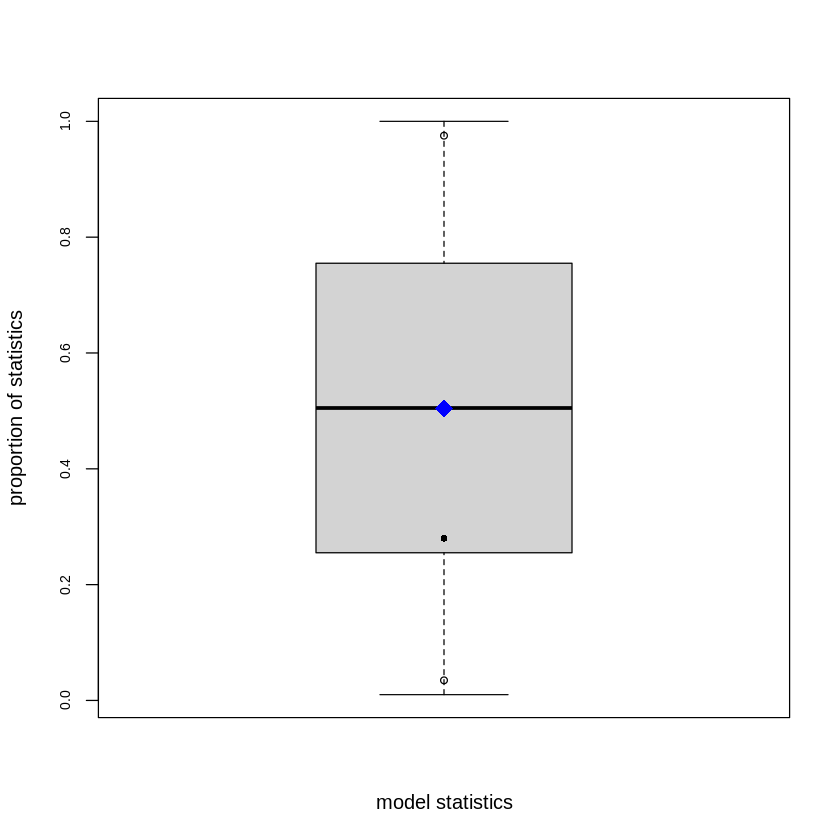

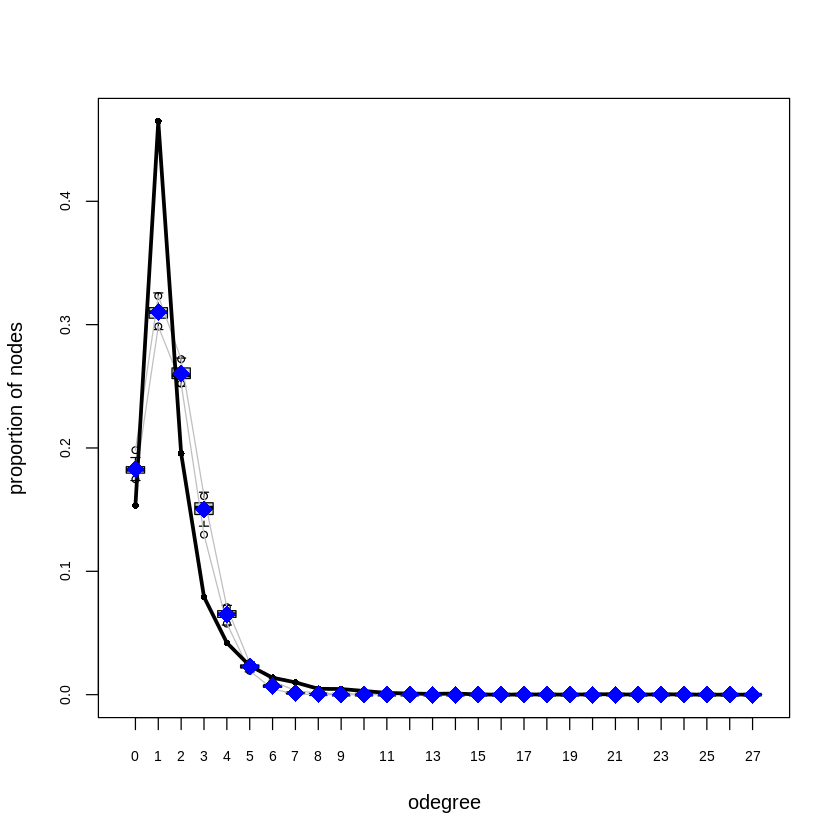

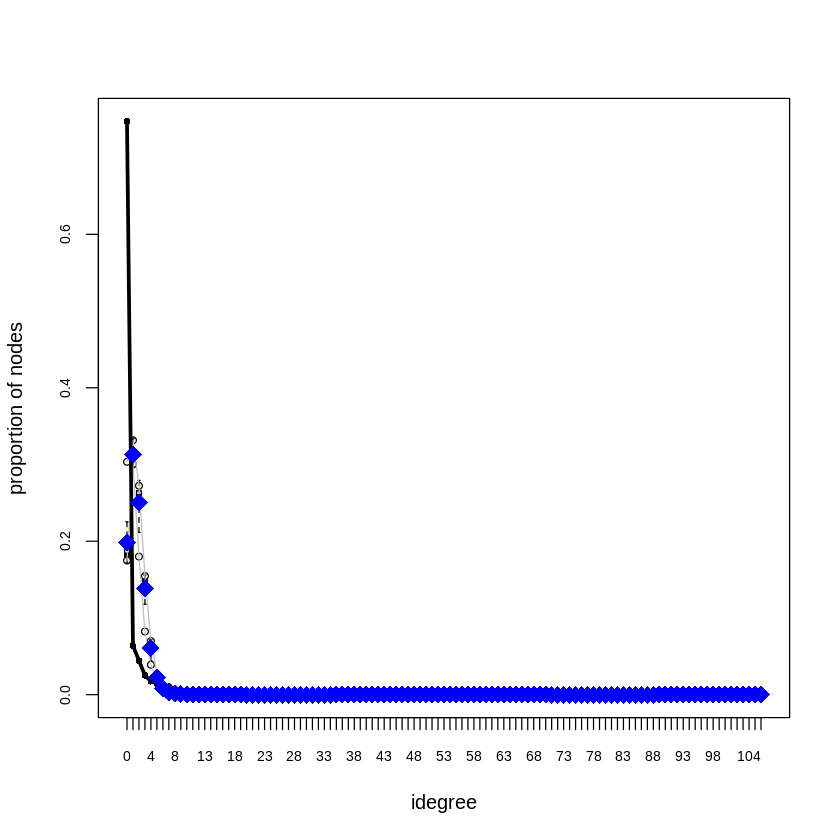

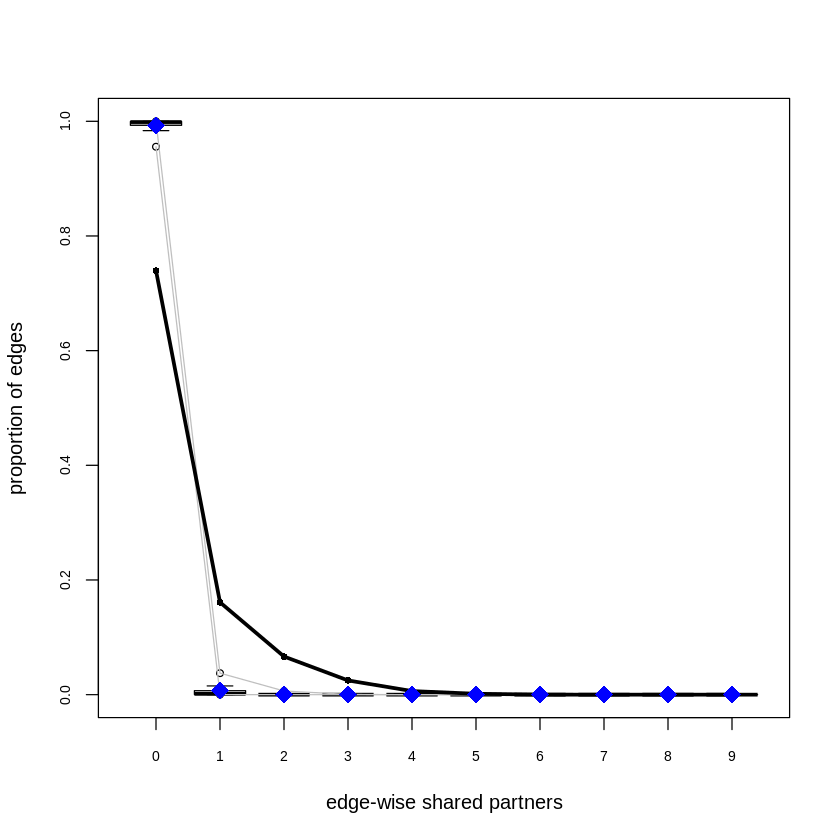

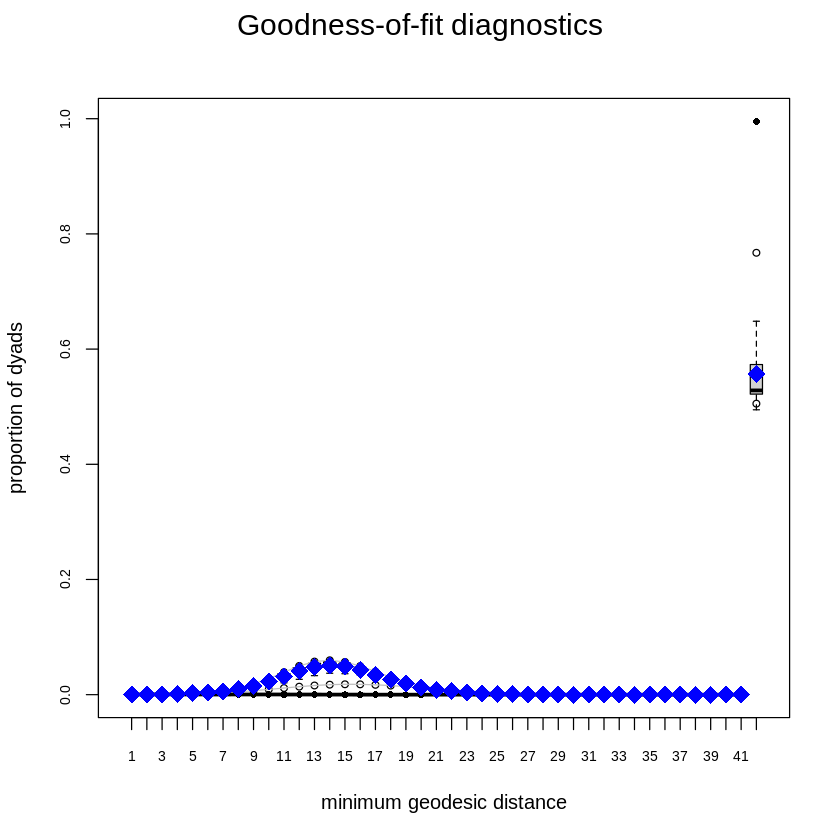

In [ ]:
plot(m1.gof)

In [ ]:
m2.gof <- gof(m2)
m2.gof


# higher p-values are good since here I want to accept H0 that the networks are the same (my simulation worked) rather than regect H0 (i.e. the networks are not the same)


Goodness-of-fit for in-degree 

            obs  min    mean  max MC p-value
idegree0   4726 1101 1215.67 2115       0.00
idegree1    403 1884 1963.27 2068       0.00
idegree2    281 1071 1649.59 1756       0.00
idegree3    159  446  914.16  990       0.00
idegree4    111  212  388.16  447       0.00
idegree5     89  108  132.55  167       0.00
idegree6     80   22   39.62   77       0.00
idegree7     66    3   11.95   52       0.00
idegree8     47    0    3.71   41       0.00
idegree9     39    0    1.69   30       0.00
idegree10    34    0    0.95   19       0.00
idegree11    23    0    0.67   13       0.00
idegree12    36    0    0.53   17       0.00
idegree13    30    0    0.40   12       0.00
idegree14    20    0    0.35    9       0.00
idegree15    18    0    0.29   10       0.00
idegree16    16    0    0.26    9       0.00
idegree17    13    0    0.11    5       0.00
idegree18     5    0    0.14    7       0.04
idegree19     8    0    0.27   14       0.02
idegree20    10    0  

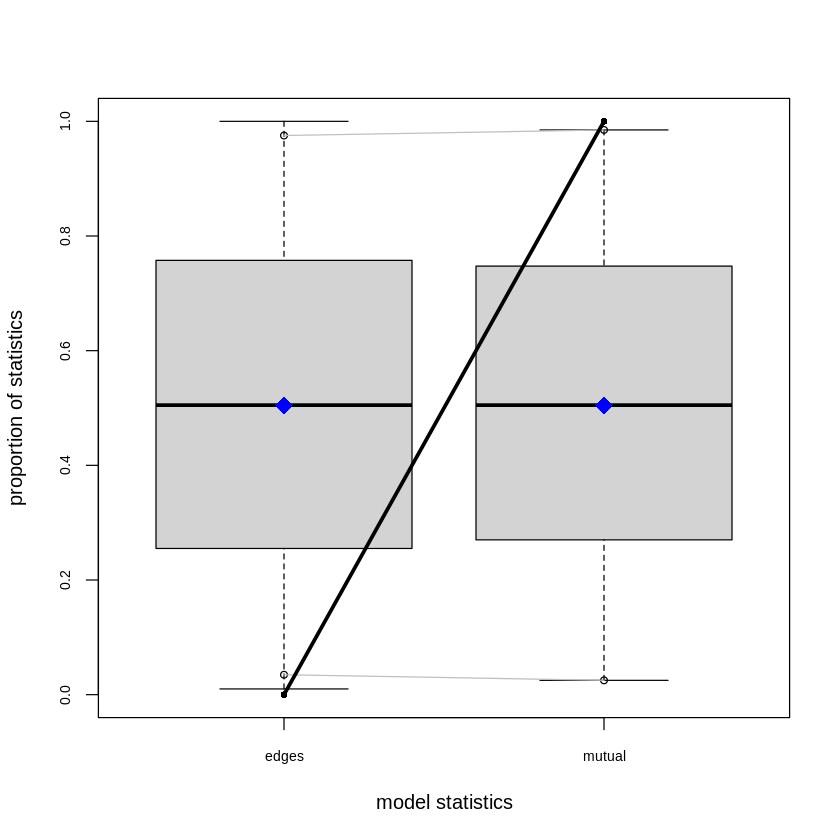

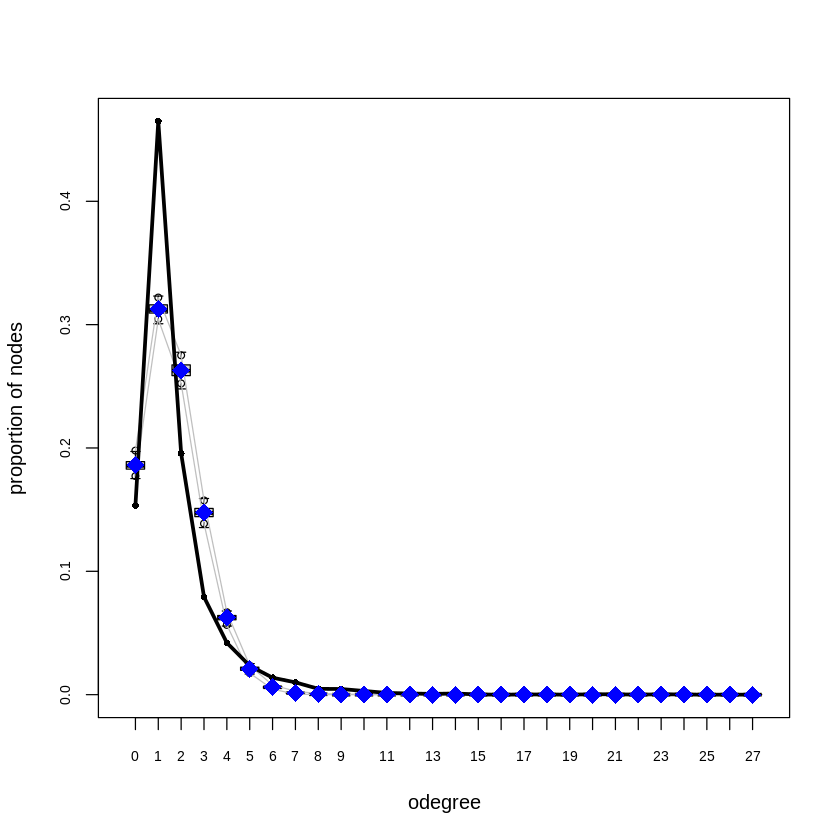

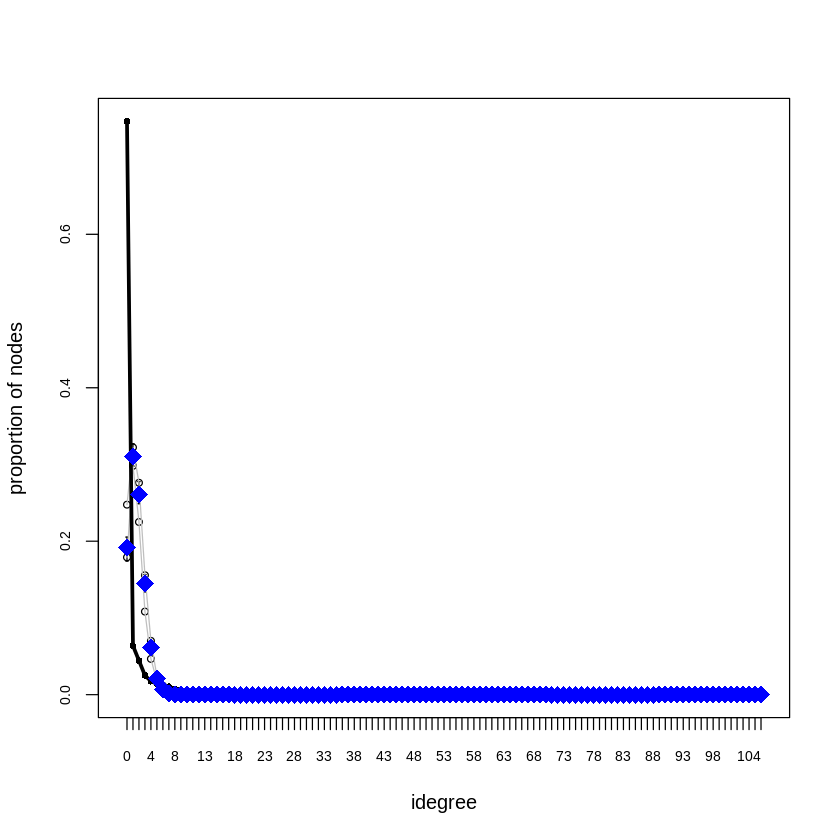

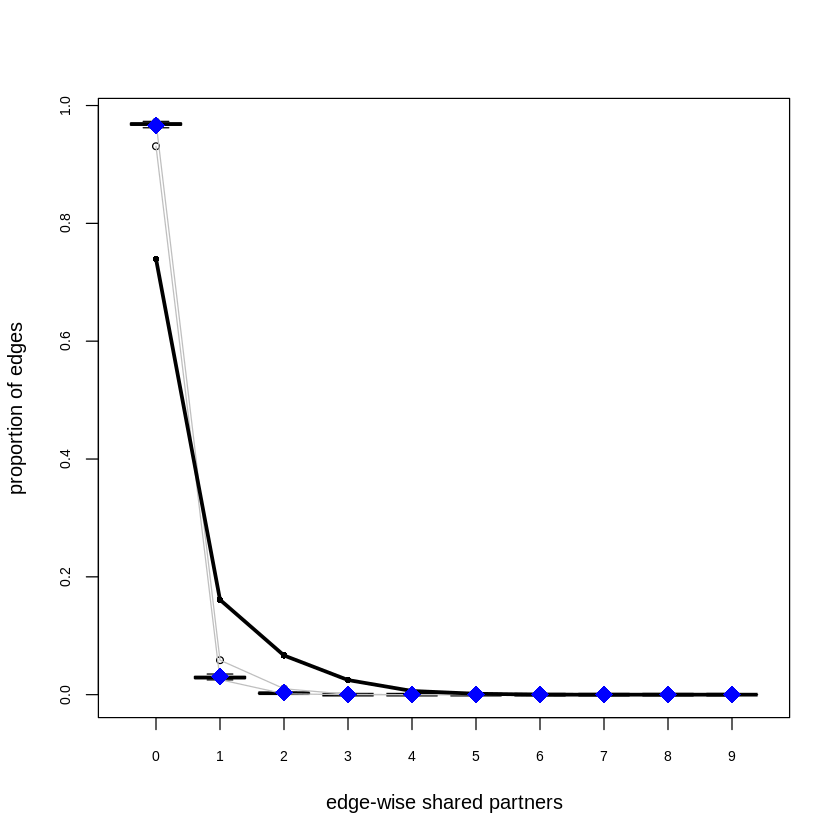

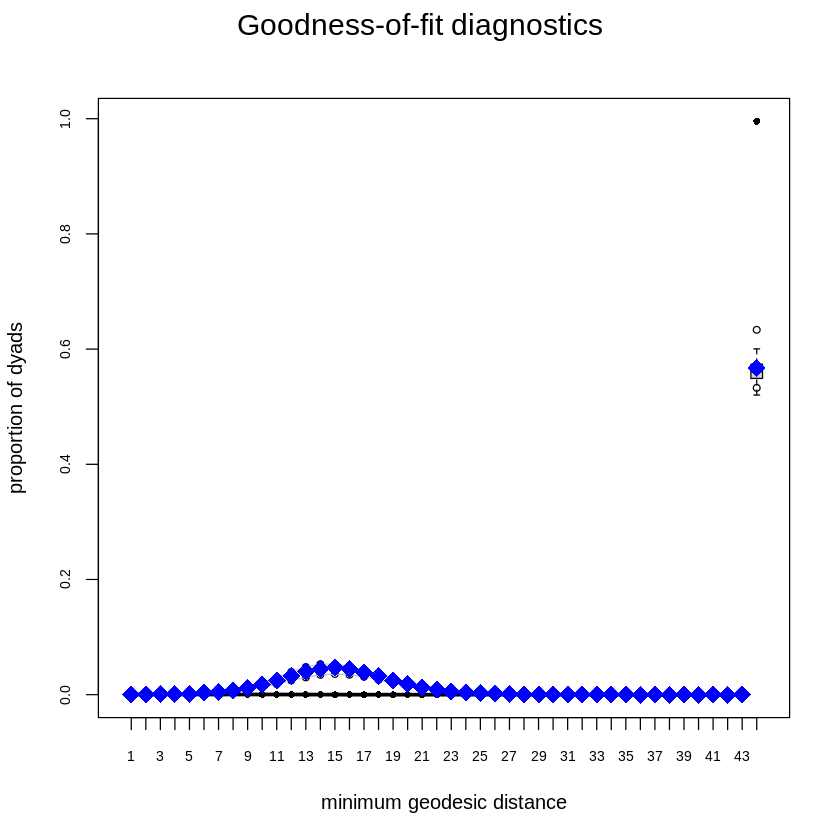

In [ ]:
plot(m2.gof)
# black solid line is the observed (original) network properties